In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import sys
import time
import json
import numpy as np
import pandas as pd
import geopandas as gpd
import pickle as pkl
import networkx as nx
import matplotlib.pyplot as plt

from scipy.stats import rv_histogram

import src
from src.reload import deep_reload

In [2]:
deep_reload(src)

atlas = src.graph.graph_from_json('atlas.json')

kw = {
    'maximum_depth': 10e3,
    'verbose': True,
    'snowball': True,
}

atlas = src.reduction.reduction(atlas, **kw)

In [3]:
atlas.number_of_nodes(), atlas.number_of_edges()

(7922, 11836)

In [4]:
'''
Reducing to GCC
'''

deep_reload(src)

atlas = src.reduction.giant_connected_component(atlas)

In [5]:
atlas.number_of_nodes(), atlas.number_of_edges()

(7890, 11812)

In [6]:
atlas = src.graph.graph_from_json('reduced_atlas.json')

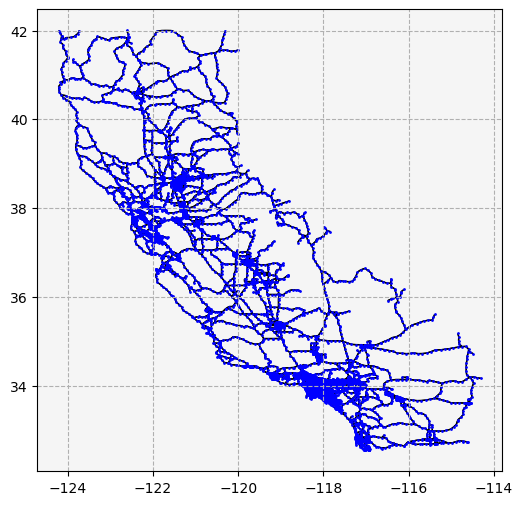

In [9]:
fig, ax = plt.subplots(figsize = (6, 6))

kw = {
    'nodes': {
        'plot': {
            's': 1,
            # 'ec': 'k',
            'fc': 'b',
            'zorder': 1,
        },
    },
    'edges': {
        'plot':{
            'lw': 1,
            'color': 'k',
            'zorder': 0,
        },
    },
}

plots = src.figures.plot_graph(atlas, ax = ax, **kw)


kw = {
    'facecolor': 'whitesmoke',
}

ax.set(**kw)

kw = {
    'ls': 'dashed',
}

ax.grid(**kw)